In [83]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import torch as t
import h5py
from glob import glob
from os.path import basename
from matplotlib.colors import LogNorm
import tifffile
import re

In [2]:
# from Damian: https://github.com/gnzng/BL7011/blob/main/BL7011/g2.py
def g2_fft_t(
    img_stack: np.ndarray, device: str = "cpu", cut_last_ratio: float = 0.5
) -> np.ndarray:
    """
    Compute the g2 correlation function using FFT.

    Parameters
    ----------
    img_stack : numpy.ndarray
        Input image stack with shape (T, H, W).
    device : str, optional
        Device to perform computations on ('cpu' or 'cuda'). Default is 'cpu'.
    cut_last_ratio : float, optional
        Ratio to cut the result length to reduce noise. Default is 0.5.

    Returns
    -------
    numpy.ndarray
        The computed g2 correlation function with reduced noise.
    """
    if len(img_stack.shape) == 2:
        img_stack = img_stack.reshape(*img_stack.shape, 1)

    # Convert to tensor and move to device
    if not isinstance(img_stack, t.Tensor):
        img_stack = t.tensor(img_stack, dtype=t.float32)
    img_stack = img_stack.to(device)

    # FFT calculations
    img_stack_padded = t.cat([img_stack, t.zeros_like(img_stack)], dim=0)
    img_stack_fft = t.fft.fft(img_stack_padded, dim=0)
    numerator_base = t.fft.ifft(img_stack_fft * img_stack_fft.conj(), dim=0)[
        : img_stack.shape[0]
    ].real

    n_elements = t.arange(img_stack.shape[0], device=device) + 1
    n_elements = n_elements.flip(0)
    numerator_base = numerator_base / n_elements.view(-1, 1, 1)

    # Denominator calculations
    lcumsum = t.roll(t.cumsum(img_stack, dim=0), 1, dims=0)
    lcumsum[0, :, :] = 0
    rcumsum = t.roll(t.cumsum(img_stack.flip(0), dim=0), 1, dims=0)
    rcumsum[0, :, :] = 0
    denominator_base = (2 * img_stack.sum(dim=0)) - lcumsum - rcumsum
    n_elements = 2 * img_stack.shape[0] - 2 * t.arange(
        img_stack.shape[0], device=device
    )
    denominator_base = denominator_base / n_elements.view(-1, 1, 1)

    # Calculate final result
    result = numerator_base / denominator_base.pow(2)

    # Remove the second half of the result because of noise
    cut_length = int(len(result) * cut_last_ratio)
    result = result[:cut_length, :, :]

    return result.cpu().numpy()

In [407]:
files = sorted(glob('./data/*xpcs*'), key = lambda s: int(re.findall(r'3\d+', basename(s))[0]))
for i, file in enumerate(files):
    print(i, basename(file))


0 YMn6Sn6_1-kz2_500ms_330K_xpcs_eda07753-a2b9-4221-9927-0166c3f5f773-022.h5
1 YMn6Sn6_1-kz2_500ms_331K_xpcs_1s_exp_a04f83a8-b9ff-4c67-9165-da6492189927-008.h5
2 YMn6Sn6_1-kz2_332K_xpcs_0d1d11b0-b040-4c82-95aa-f49f2397d437-013.h5
3 YMn6Sn6_1-kz2_333K_xpcs_002451e1-2af0-47bd-bc36-d029840e6cc4-011.h5
4 YMn6Sn6_1-kz2_334K_xpcs_5b7b38f6-9c1f-4bf1-8a1b-d3ecc32e0370-012.h5
5 YMn6Sn6_1-kz2_335K_xpcs_dcaadec2-0f6a-4e33-a711-ce21659217ce-023.h5
6 YMn6Sn6_1-kz2_336K_xpcs_cc4082d4-bb1a-4ea1-a9b3-e02670b1fd58-003.h5
7 YMn6Sn6_1-kz2_337K_xpcs_a7d46c05-fb1a-4bd9-a20f-802e4498ddba-002.h5
8 YMn6Sn6_1-kz2_338K_xpcs_2s_exp_last_57d25e25-3d71-4c78-a3bf-b872855c8c22-004.h5
9 YMn6Sn6_1-kz2_338K_xpcs_a59f30e0-abd8-46b3-a3db-9ddc7aad44f6-017.h5
10 YMn6Sn6_AF_340K_xpcs_1d2f1b68-d45e-420b-9280-c4aa8d76738a-009.h5


In [408]:
file = files[9]
with h5py.File(file, 'r') as f:
    print(f.keys())
    print(f['entry1'].keys())
    print(f['entry1']['instrument_1'].keys())
    print(f['entry1']['instrument_1']['detector_1'].keys())
    imgs = np.squeeze(f['entry1']['instrument_1']['detector_1']['data'][:]).astype(float)
    temp = int(re.findall(r'3\d+', basename(file))[0])

<KeysViewHDF5 ['entry1']>
<KeysViewHDF5 ['end_time', 'instrument_1', 'run_id', 'sample_1', 'start_time']>
<KeysViewHDF5 ['detector_1', 'labview_data', 'name', 'source_1']>
<KeysViewHDF5 ['count_time', 'data', 'description', 'detector_readout_time', 'distance', 'exposures', 'period', 'x_pixel_size', 'y_pixel_size']>


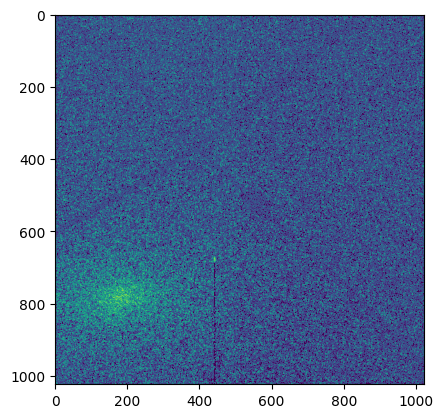

In [409]:
plt.figure()
plt.imshow(imgs[0], norm=LogNorm())
plt.show()

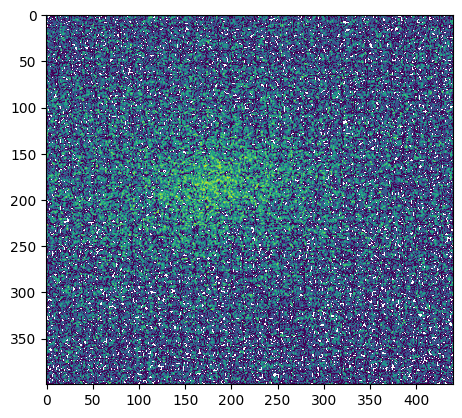

In [410]:
roi = np.s_[..., 600:1000, :440]
plt.figure()
plt.imshow(imgs[roi][0], norm=LogNorm())
plt.show()

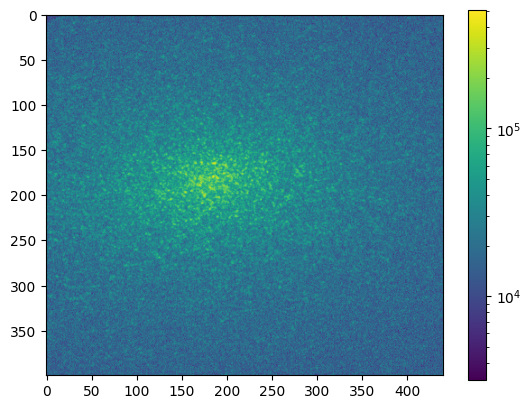

In [411]:
img = imgs[roi].sum(axis=0)
plt.figure()
plt.imshow(img, norm=LogNorm())
plt.colorbar()
plt.show()

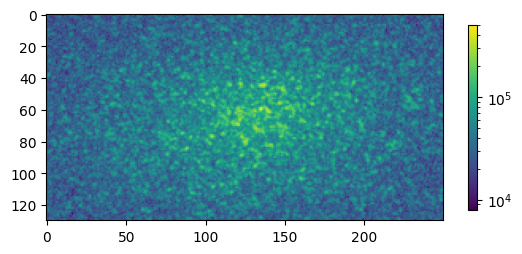

In [412]:
groi = np.s_[..., 120:250, 50:300]
plt.imshow(img[groi], norm=LogNorm())
plt.colorbar(shrink=0.5)
plt.show()

In [413]:
g2 = g2_fft_t(imgs[groi]/np.expand_dims((imgs[groi].mean(axis=(1,2))), axis=(1,2)))

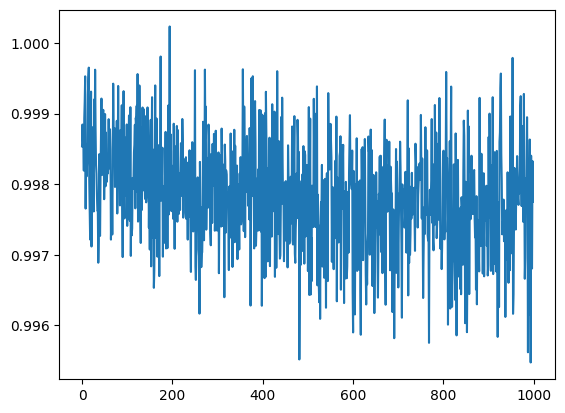

In [414]:
g = g2.mean(axis=(1,2))
plt.plot(g[1:])


In [417]:
tifffile.imwrite(f'./data/tiff/{temp}K_xpcs_2sexp.tiff', imgs[roi])

In [418]:
np.save(f'./data/results/{temp}K_g2_2s.npy', g)

In [375]:
files = glob('./data/results/*')
g2s = []
temps = []
for i, file in enumerate(sorted(files)[1:-1]):
    print(i, basename(file))
    g2s.append(np.load(file)[:1000])
    temps.append(int(basename(file)[:3]))

g2s = np.asarray(g2s)
temps = np.asarray(temps)

0 331K_g2.npy
1 332K_g2.npy
2 333K_g2.npy
3 334K_g2.npy
4 335K_g2.npy
5 336K_g2.npy
6 337K_g2.npy
7 338K_g2.npy


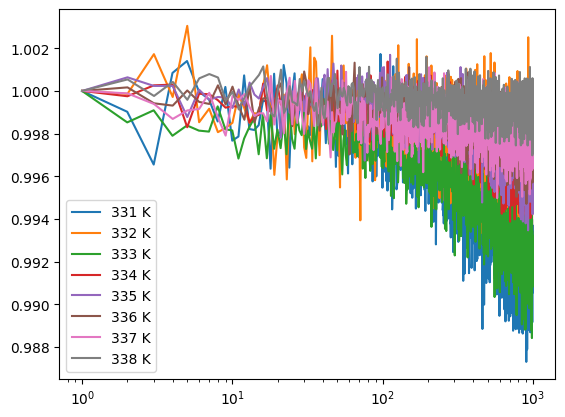

In [ ]:
plt.figure()
for i, g_ in enumerate(g2s):
    plt.plot(np.arange(len(g_))[1:]/g_[1], g_[1:]/g_[1], label=f'{temps[i]} K')

plt.semilogx()
plt.legend()
plt.show()

In [384]:
g2s.shape

(8, 1000)

In [395]:
from scipy.ndimage import gaussian_filter

g_g2s = gaussian_filter(g2s[:,1:], sigma=(0,3))

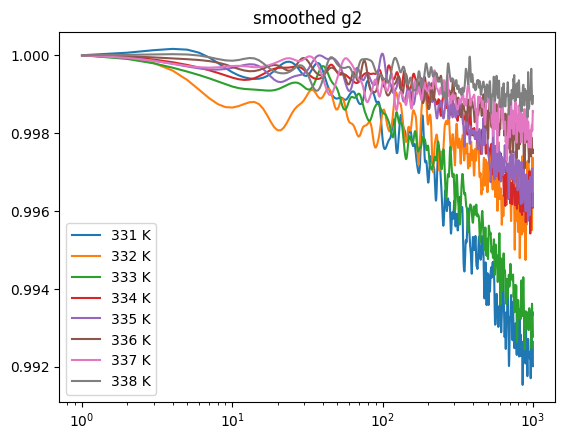

In [419]:
plt.figure()
plt.title('smoothed g2')
for i, g_ in enumerate(g_g2s):
    plt.plot(np.arange(1, len(g_)), g_[1:]/g_[1], label=f'{temps[i]} K')

plt.semilogx()
plt.legend()
plt.show()